## Analyzing long-term algebraic endemic prevalence for different values of $\epsilon_1$ and $\epsilon_2$ in the SIRCmw model (algebraic version)

Instead of integrating the ODE system via simulations, we solve for the exact endemic equilibrium algebraically and then compute the analytical Jacobian at each root to determine its stability

Instead of using a standard numerical solver, we use the reduced expression in I and use brentq, since fsolve would rely on the initial guess and would only return one root 


In [1]:
#Import stuff
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator


In [2]:
#Read data
prevalence_results = np.load("prevalence_roots_results.npz")
list_eps1 = prevalence_results['list_eps1']
list_eps2 = prevalence_results['list_eps2']
prevalences = prevalence_results['prevalences']
stabilities = prevalence_results['stabilities']

# Keep only values of tilde epsilon >= 0
mask1 = list_eps1 >= 0
mask2 = list_eps2 >= 0
list_eps1 = list_eps1[mask1]
list_eps2 = list_eps2[mask2]
prevalences = prevalences[mask1][:, mask2]
stabilities = stabilities[mask1][:, mask2]


Text(0.5, 1.0, 'Zoomed High Prevalence')

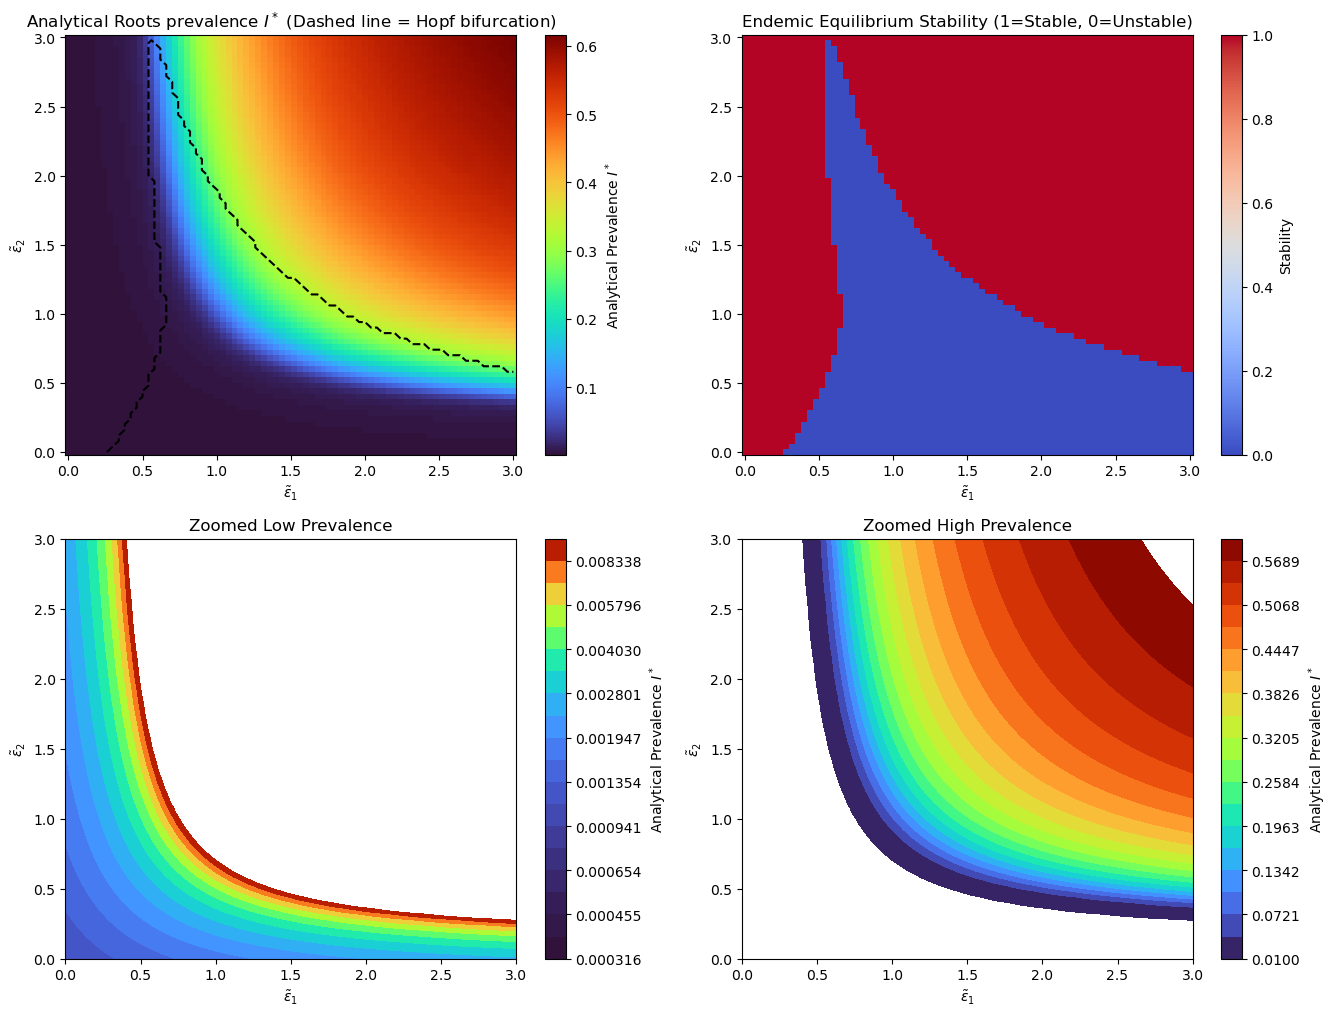

In [3]:
#Plot both together
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()
# Prevalence plot
im1 = axs[0].pcolormesh(list_eps1, list_eps2, prevalences, cmap='turbo', shading='auto')
# Draw stability contour
axs[0].contour(list_eps1, list_eps2, stabilities, levels=[0.5], colors='black', linestyles='--')
axs[0].set_xlabel(r'$\tilde{\epsilon}_1$')
axs[0].set_ylabel(r'$\tilde{\epsilon}_2$')
axs[0].set_title('Analytical Roots prevalence $I^*$ (Dashed line = Hopf bifurcation)')
fig.colorbar(im1, ax=axs[0], label='Analytical Prevalence $I^*$')

# Stability plot
im2 = axs[1].pcolormesh(list_eps1, list_eps2, stabilities, cmap='coolwarm', shading='auto')
axs[1].set_xlabel(r'$\tilde{\epsilon}_1$')
axs[1].set_ylabel(r'$\tilde{\epsilon}_2$')
axs[1].set_title('Endemic Equilibrium Stability (1=Stable, 0=Unstable)')
fig.colorbar(im2, ax=axs[1], label='Stability')

#More detail on the low-prevalence region
pcm = axs[2].contourf(list_eps1, list_eps2, prevalences, levels=np.logspace(-3.5, -2., 20), cmap='turbo')
fig.colorbar(pcm, ax=axs[2], label='Analytical Prevalence $I^*$')
axs[2].set_xlabel(r'$\tilde{\epsilon}_1$')
axs[2].set_ylabel(r'$\tilde{\epsilon}_2$')
axs[2].set_title('Zoomed Low Prevalence')

#More detail on the high-prevalence region
pcm = axs[3].contourf(list_eps1, list_eps2, prevalences, levels=np.linspace(0.01, 0.6, 20), cmap='turbo')
fig.colorbar(pcm, ax=axs[3], label='Analytical Prevalence $I^*$')
axs[3].set_xlabel(r'$\tilde{\epsilon}_1$')
axs[3].set_ylabel(r'$\tilde{\epsilon}_2$')
axs[3].set_title('Zoomed High Prevalence')


The axis at the top-left indicates the analytical endemic prevalence of infection $I^*$. The dashed contour line denotes the boundary between stable and unstable regions (Hopf bifurcation). Inside the dashed loop, the endemic equilibrium becomes unstable, and the system exhibits sustained limit-cycle oscillations. 

The axis at the top-right displays the stability of the endemic equilibrium directly (derived from the eigenvalues of the analytical Jacobian). This replaces the "Reseed count" plot from the simulation version, which was a numerical artifact of the simulation approach.


### Plotting slices of the surface

This gives us a better idea of the overall behavior.


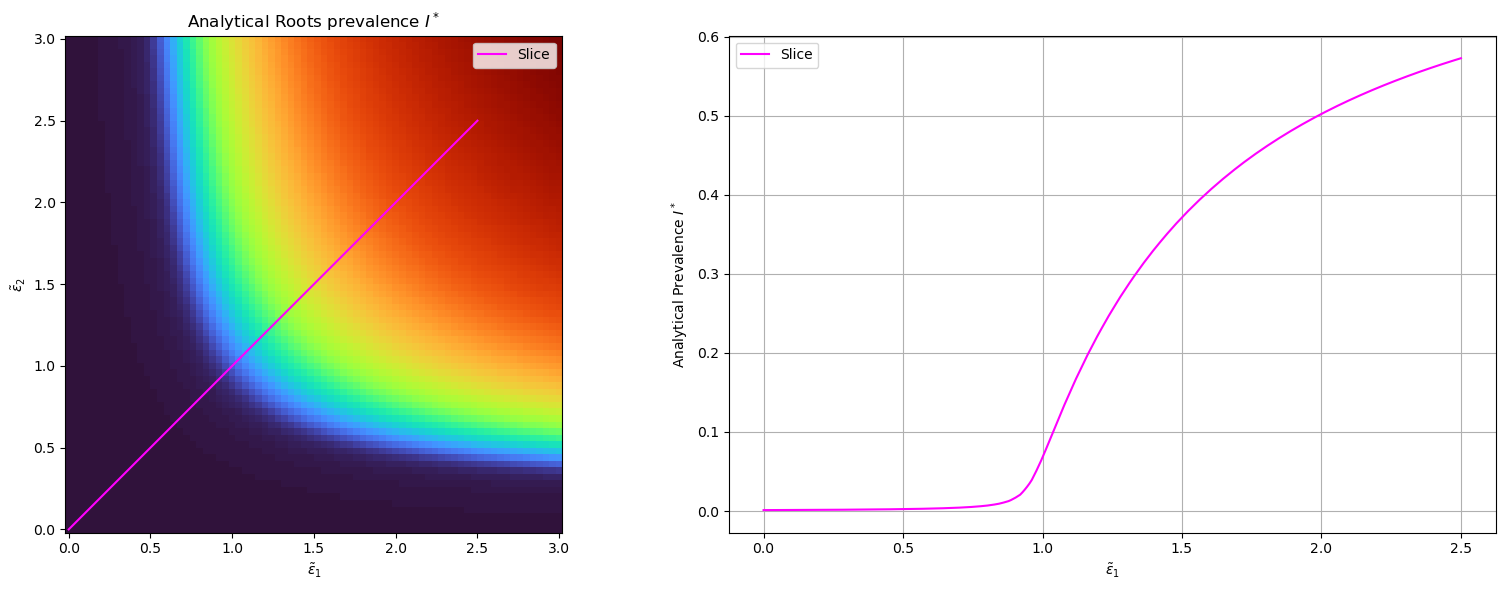

In [4]:
interp = RegularGridInterpolator(
    (list_eps1, list_eps2),
    prevalences,
    method='linear',        
    bounds_error=False,
    fill_value=np.nan, 
)
eps1_a, eps2_a = 0.0, 0.0
eps1_b, eps2_b = 2.5, 2.5

# Define the line by two endpoints in (eps1, eps2) space
p_start = np.array([eps1_a, eps2_a])
p_end   = np.array([eps1_b, eps2_b])

n = 300
t = np.linspace(0, 1, n)
line = p_start + t[:, None] * (p_end - p_start)   # shape (n, 2): col 0 = eps1, col 1 = eps2

# Query order must match the grid: (eps1, eps2)
profile = interp(line)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.pcolormesh(list_eps1, list_eps2, prevalences, cmap='turbo', shading='auto')
ax1.plot(line[:, 1], line[:, 0], color='magenta', label='Slice')
ax1.set_xlabel(r'$\tilde{\epsilon}_1$')
ax1.set_ylabel(r'$\tilde{\epsilon}_2$')
ax1.set_title('Analytical Roots prevalence $I^*$')
ax1.legend()


ax2.plot(np.linspace(eps1_a, eps1_b, n), profile, color='magenta',label='Slice' )
ax2.set_xlabel(r'$\tilde{\epsilon}_1$')
ax2.set_ylabel('Analytical Prevalence $I^*$')
ax2.legend()

ax2.grid()
#Fix ratio of axes
ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()


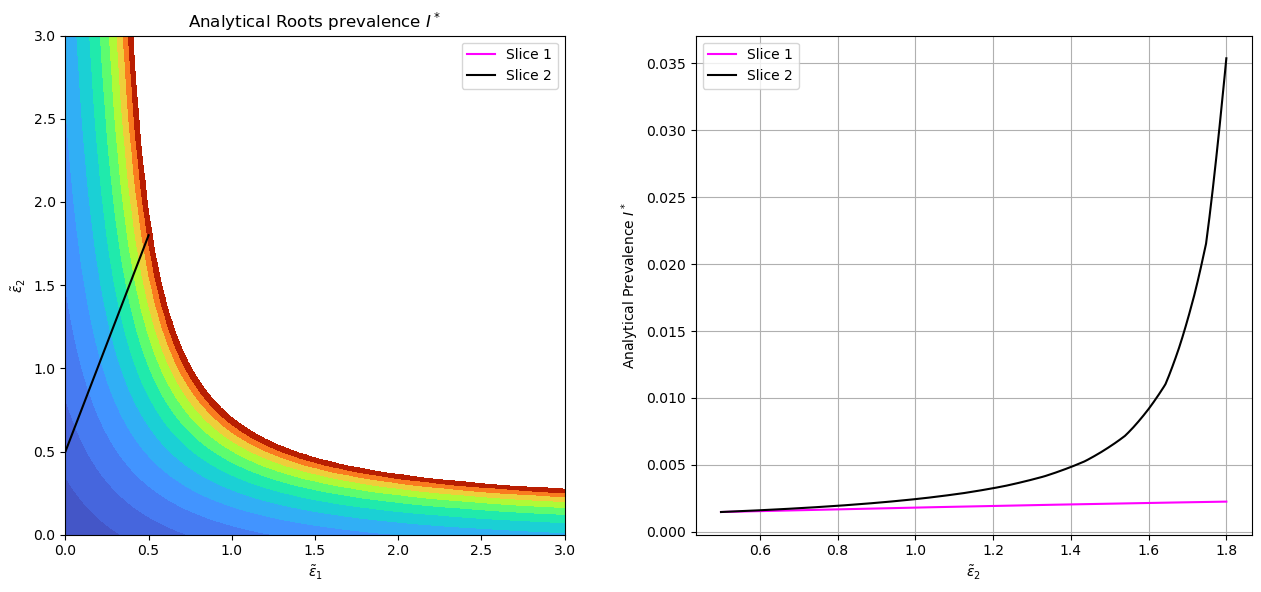

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
ax1.contourf(list_eps1, list_eps2, prevalences, levels=np.logspace(-3.5, -2., 20), cmap='turbo')
ax1.set_xlabel(r'$\tilde{\epsilon}_1$')
ax1.set_ylabel(r'$\tilde{\epsilon}_2$')
ax1.set_title('Analytical Roots prevalence $I^*$')

#Acrross an approximate level curve
eps1_a, eps2_a = 0.0, 0.5
eps1_b, eps2_b = 0.0, 1.8

# Define the line by two endpoints in (eps1, eps2) space
p_start = np.array([eps1_a, eps2_a])
p_end   = np.array([eps1_b, eps2_b])
n = 300
t = np.linspace(0, 1, n)
line1 = p_start + t[:, None] * (p_end - p_start)   # shape (n, 2): col 0 = eps1, col 1 = eps2
# Query order must match the grid: (eps1, eps2)
profile1 = interp(line1)
ax1.plot(line1[:, 0], line1[:, 1], color='magenta', label='Slice 1')
ax2.plot(np.linspace(eps2_a, eps2_b, n), profile1, color='magenta',label='Slice 1' )


#Across several level curves
eps1_a, eps2_a = 0, 0.5
eps1_b, eps2_b = 0.5, 1.8
# Define the line by two endpoints in (eps1, eps2) space
p_start = np.array([eps1_a, eps2_a])
p_end   = np.array([eps1_b, eps2_b])
n = 300
t = np.linspace(0, 1, n)
line1 = p_start + t[:, None] * (p_end - p_start)   # shape (n, 2): col 0 = eps1, col 1 = eps2
# Query order must match the grid: (eps1, eps2)
profile1 = interp(line1)
ax1.plot(line1[:, 0], line1[:, 1], color='k', label='Slice 2')
ax2.plot(np.linspace(eps2_a, eps2_b, n), profile1, color='k',label='Slice 2' )


ax2.set_xlabel(r'$\tilde{\epsilon}_2$')
ax2.set_ylabel('Analytical Prevalence $I^*$')
ax2.legend()
#Gray background
# ax2.set_facecolor('gray')
ax2.grid()
#Fix ratio of axes

ax1.legend()

ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()
